## Google Colab Setup

In [ ]:
!rm -rf /content/drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Setup & Load YOLOv8n

Start by loading a pretrained YOLOv8n model. This model was trained on the COCO dataset and serves as the baseline before any fine-tuning on the VisDrone dataset.

In [ ]:
# Install YOLOv8
!pip install -q ultralytics

# Import and load pretrained YOLOv8n
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

print("YOLOv8n loaded successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8n loaded successfully


## Download Dataset

Download the VisDrone dataset directly from Kaggle to avoid slow manual uploads.


In [ ]:
# Install Kaggle CLI
!pip -q install kaggle

# Create Kaggle config directory
!mkdir -p ~/.kaggle

# Move API key and set permissions
!cp "/content/drive/My Drive/kaggle.json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

# Download and unzip VisDrone dataset
!kaggle datasets download -d banuprasadb/visdrone-dataset -p /content --unzip

# Check if data exists
!ls /content

Dataset URL: https://www.kaggle.com/datasets/banuprasadb/visdrone-dataset
License(s): GNU Affero General Public License 3.0
 99% 2.07G/2.10G [00:17<00:00, 184MB/s]
100% 2.10G/2.10G [00:17<00:00, 128MB/s]
drive  sample_data  VisDrone_Dataset  yolov8n.pt


## Dataset Sanity Check

Verify that the expected folders exist and that the YAML file points to the correct train/val/test directories.

In [ ]:
import os

DATA_ROOT = "/content/VisDrone_Dataset"

# Top-level contents
!ls "{DATA_ROOT}"

# Train / Val / Test folders
!ls "{DATA_ROOT}/VisDrone2019-DET-train"
!ls "{DATA_ROOT}/VisDrone2019-DET-val"
!ls "{DATA_ROOT}/VisDrone2019-DET-test-dev"
!ls "{DATA_ROOT}/VisDrone2019-DET-test-challenge"

# Check YAML file exists
!ls "{DATA_ROOT}/visdrone.yaml"

VisDrone2019-DET-test-challenge  VisDrone2019-DET-train  visdrone.yaml
VisDrone2019-DET-test-dev	 VisDrone2019-DET-val
images	labels
images	labels
images	labels
images
/content/VisDrone_Dataset/visdrone.yaml


## Dataset Exploration

Examine the VisDrone dataset to understand the visual characteristics of the data. VisDrone consists of high-resolution aerial images with dense scenes and many small, overlapping objects, which makes detection particularly challenging. Displayed are a few randomly selected images from the validation split to illustrate typical scenes.

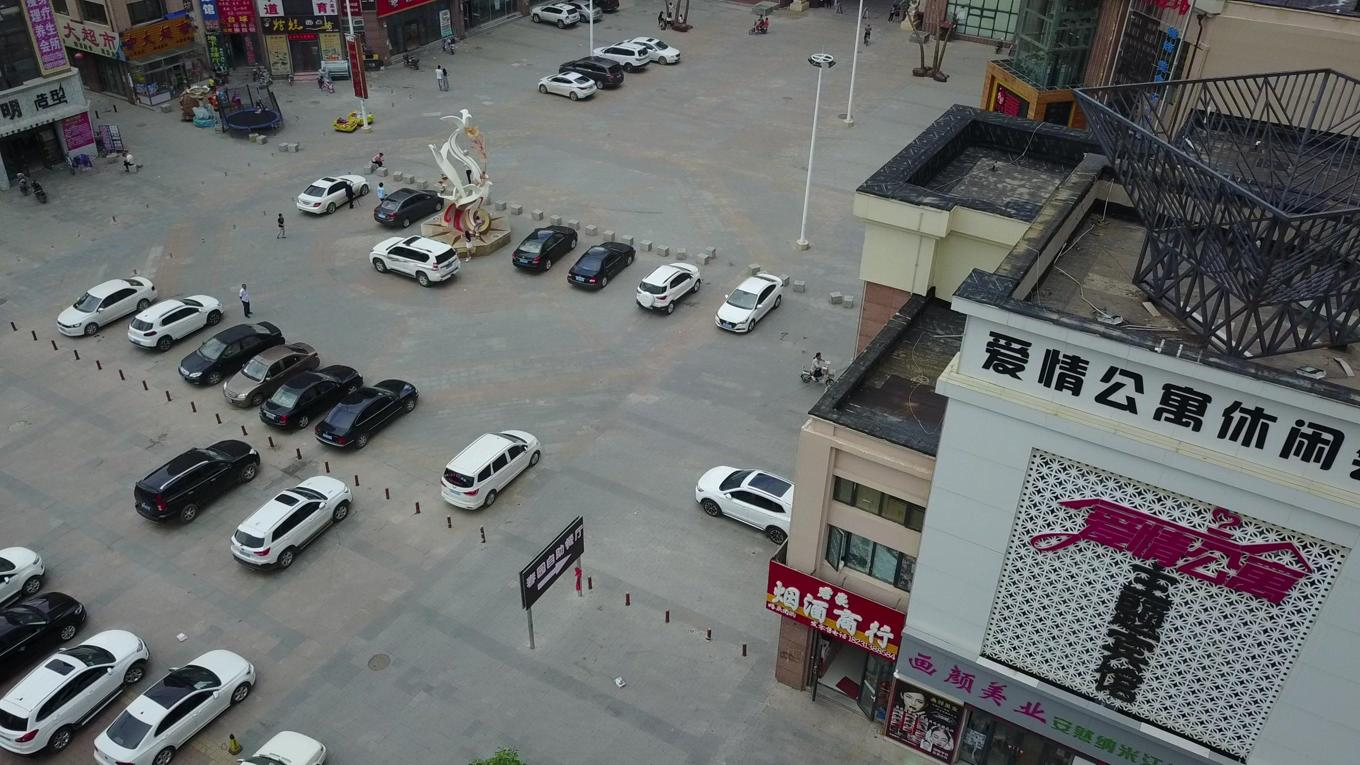

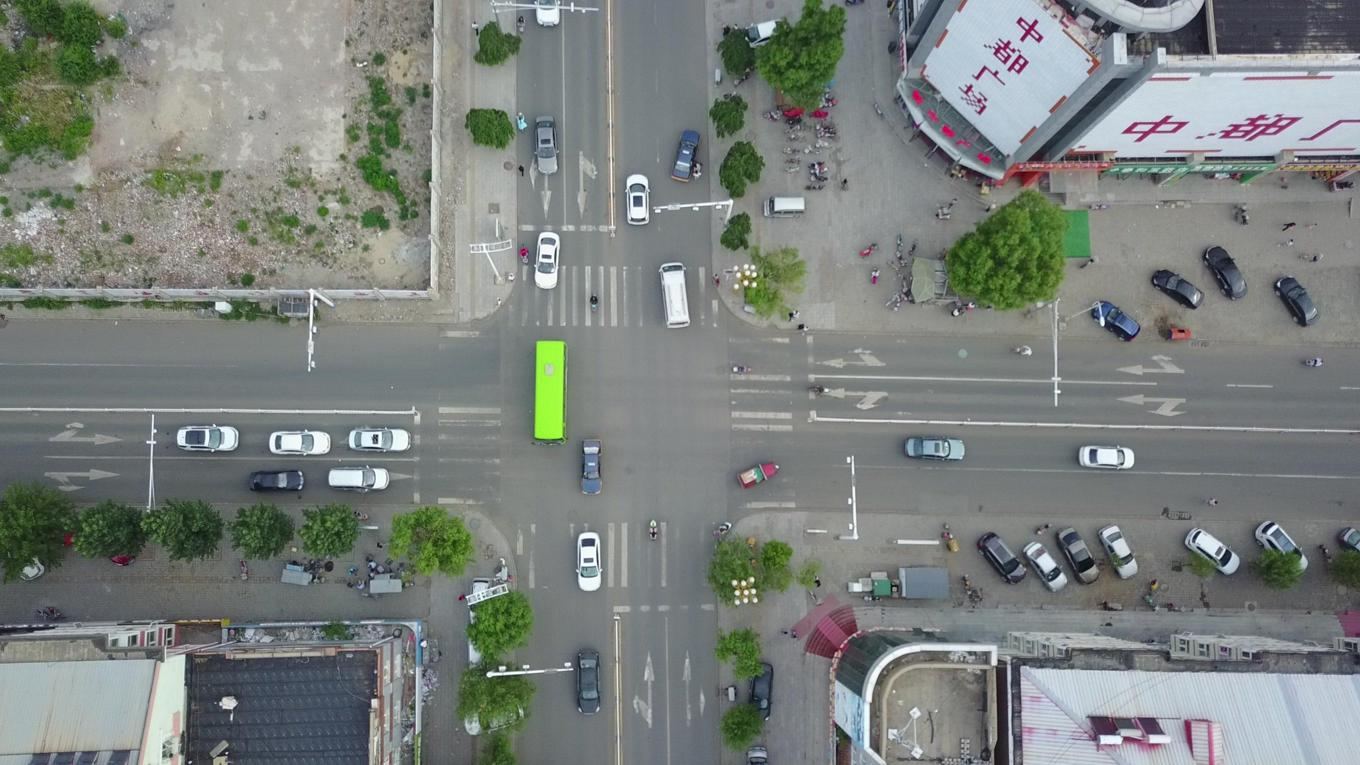

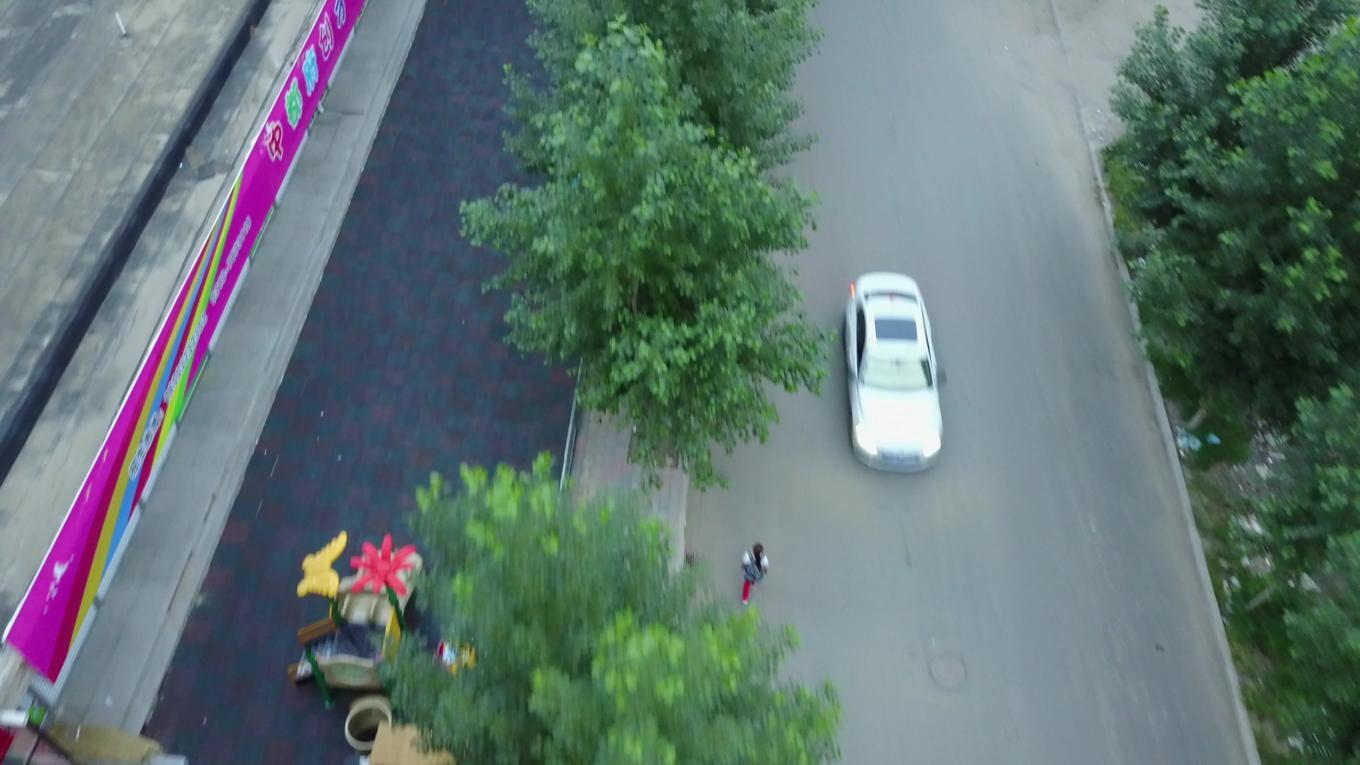

In [ ]:
import os, random
from IPython.display import Image, display

# Path to validation images
val_img_dir = "/content/VisDrone_Dataset/VisDrone2019-DET-val/images"

# Randomly select 3 images
all_imgs = [f for f in os.listdir(val_img_dir) if f.endswith(".jpg")]
sample_imgs = random.sample(all_imgs, 3)

# Display images
for img_name in sample_imgs:
    display(Image(filename=os.path.join(val_img_dir, img_name)))


## Baseline Evaluation

Evaluate the pretrained YOLOv8n model on the VisDrone validation set to establish a baseline before any fine-tuning.

In [ ]:
metrics = model.val(data="/content/VisDrone_Dataset/visdrone.yaml")

Ultralytics 8.3.239 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2269.9±665.4 MB/s, size: 131.0 KB)
val: Scanning /content/VisDrone_Dataset/VisDrone2019-DET-val/labels... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 1.4Kit/s 0.4s
val: New cache created: /content/VisDrone_Dataset/VisDrone2019-DET-val/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 2.8it/s 12.5s
                   all        548      38759     0.0638     0.0488     0.0307      0.014
                person        520       8844      0.274      0.179      0.143      0.061
               bicycle        482       5125      0.072   0.000976     0.0474     0.0152
                   car        364       1287    0.00221      0.028    0.00146   0.000473
            motorcycle        515

**Baseline observation:**  

The pretrained YOLOv8n model performs very poorly on VisDrone, with an overall mAP50 of ~0.03 and extremely low recall for most classes. This is expected, as the model was trained on COCO and has not been adapted to VisDrone's dense scenes and small-object scale distribution. These results establish a clear baseline and motivate fine-tuning for small-object detection.


## Baseline Qualitative Results

Visualize example detections from the pretrained YOLOv8n model on a specific image in the VisDrone validation set. The result illustrate typical failure modes for small and densely packed objects prior to fine-tuning.

In [ ]:
# Imports
import os, glob, shutil
from IPython.display import Image, display

Results saved to /content/runs/detect/baseline


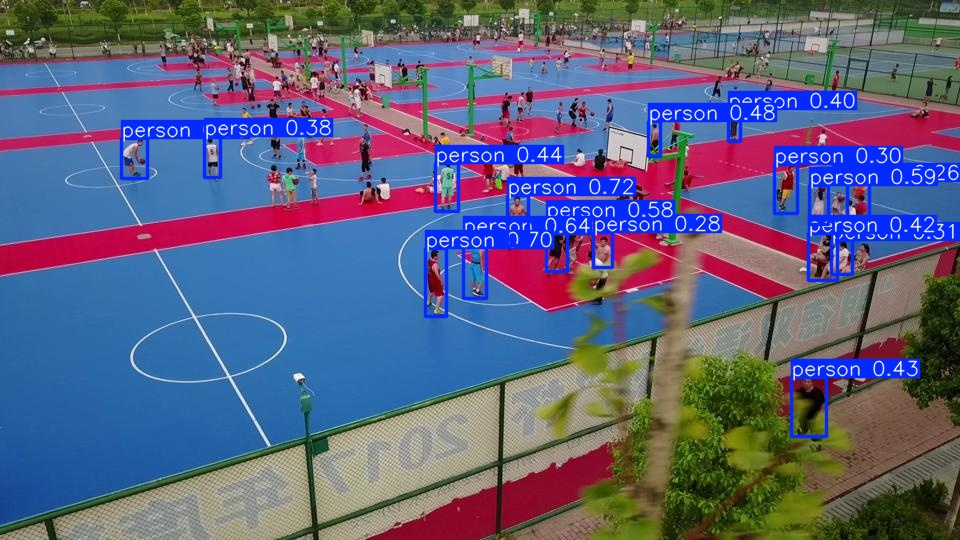

In [ ]:
fixed_img = "/content/VisDrone_Dataset/VisDrone2019-DET-val/images/0000086_01443_d_0000004.jpg"

run_dir = "/content/runs/detect/baseline"

if os.path.exists(run_dir):
    shutil.rmtree(run_dir)

# Predict
model.predict(
    source=fixed_img,
    conf=0.25,
    iou=0.5,
    save=True,
    max_det=300,
    verbose=False,
    project="/content/runs/detect",
    name="baseline"
)

# Display result
saved = sorted(glob.glob(os.path.join(run_dir, "**", "*.jpg"), recursive=True))
if not saved:
    raise FileNotFoundError(f"No saved .jpg found under {run_dir}.")
display(Image(filename=saved[0]))


**Observation:**
  
The pretrained YOLOv8n model performs reasonably well on this image, primarily because the dominant class is *person*, which is also present in the COCO dataset used for pretraining. However, detections are often imprecise and many small or distant individuals are missed. Performance on other VisDrone-specific classes (e.g., vehicles) remains significantly weaker, as reflected in the low overall mAP.


## Fine-Tuning YOLOv8n on VisDrone (Small-Object Training)

Fine-tune a COCO-pretrained YOLOv8n model on the VisDrone training split to adapt the detector to dense scenes and small objects.  
To improve small-object performance, we make two intentional changes relative to the baseline:

1. **Fine-tuning** on VisDrone (train on `DET-train`, validate on `DET-val`).
2. **Higher input resolution** (`imgsz`) to preserve small-object detail.

Keep the model lightweight (YOLOv8n) to fit within Colab GPU constraints.


In [ ]:
# Start from COCO-pretrained YOLOv8n
ft_model = YOLO("yolov8n.pt")

results = ft_model.train(
    data="/content/VisDrone_Dataset/visdrone.yaml",
    epochs=10,
    imgsz=768,
    batch=4,
    device=0,
    workers=2,
    augment=True,
    cache=False
)

# sync most recent run to Drive/latest
LATEST_DIR = "/content/drive/MyDrive/EE428_results/latest"
src = str(results.save_dir)

if os.path.exists(LATEST_DIR):
    shutil.rmtree(LATEST_DIR)

shutil.copytree(src, LATEST_DIR)
print("Updated latest from:", src)

Ultralytics 8.3.239 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/VisDrone_Dataset/visdrone.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, 

## Quantitative Results Comparison (Baseline vs Fine-tuned)

The table below compares validation performance before and after fine-tuning.

- **Baseline:** COCO-pretrained YOLOv8n evaluated on VisDrone val (no fine-tuning)
- **Fine-tuned:** YOLOv8n fine-tuned on VisDrone (10 epochs, imgsz=768, augmentation enabled), evaluated on VisDrone val

In [ ]:
import pandas as pd

# Baseline metrics
base = metrics

# Evaluate fine-tuned model on the SAME val split for a clean comparison
LATEST_DIR = "/content/drive/MyDrive/EE428_results/latest"
BEST_WEIGHTS = os.path.join(LATEST_DIR, "weights", "best.pt")
ft_eval_model = YOLO(BEST_WEIGHTS)

imp = ft_eval_model.val(data="/content/VisDrone_Dataset/visdrone.yaml", imgsz=768, verbose=False)

def row(name, m):
    return {
        "Setting": name,
        "Precision (P)": float(m.box.mp),
        "Recall (R)": float(m.box.mr),
        "mAP50": float(m.box.map50),
        "mAP50-95": float(m.box.map),
    }

df = pd.DataFrame([
    row("Baseline (YOLOv8n COCO)", base),
    row("Fine-tuned (10 epochs, imgsz=768, aug)", imp),
])

display(df)


Ultralytics 8.3.239 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3881.0±661.9 MB/s, size: 319.7 KB)
val: Scanning /content/VisDrone_Dataset/VisDrone2019-DET-val/labels.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 756.3Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 2.7it/s 12.8s
                   all        548      38759      0.387      0.303       0.29      0.171
Speed: 1.6ms preprocess, 3.5ms inference, 0.0ms loss, 4.4ms postprocess per image
Results saved to /content/runs/detect/val2


,Setting,Precision (P),Recall (R),mAP50,mAP50-95
0,Baseline (YOLOv8n COCO),0.063786,0.048800,0.030673,0.013976
1,"Fine-tuned (10 epochs, imgsz=768, aug)",0.387114,0.303368,0.289768,0.171390


**Discussion:**  

Fine-tuning YOLOv8n on the VisDrone dataset resulted in a substantial quantitative improvement.  
The baseline mAP50 of ~0.03 increased to ~0.28 after fine-tuning (imgsz=768, 10 epochs), indicating that pretrained COCO weights adapt effectively to dense, small-object scenarios when trained on domain-specific data.

## Qualitative Evaluation

To complement the quantitative results, we examine detection outputs on a fixed validation image.

Results saved to /content/drive/MyDrive/EE428_results/latest/qual


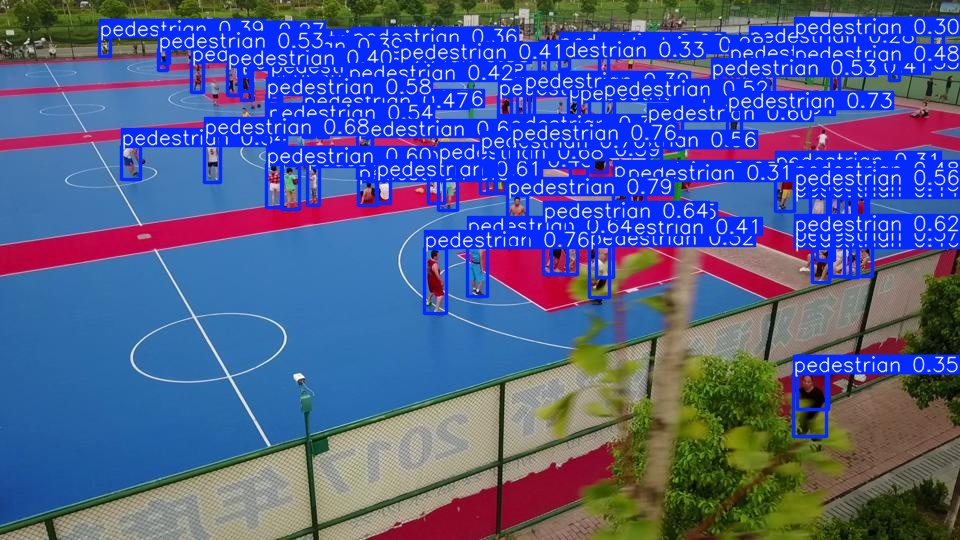

In [ ]:
LATEST_DIR = "/content/drive/MyDrive/EE428_results/latest"
BEST_WEIGHTS = os.path.join(LATEST_DIR, "weights", "best.pt")

ft_best = YOLO(BEST_WEIGHTS)

fixed_img = "/content/VisDrone_Dataset/VisDrone2019-DET-val/images/0000086_01443_d_0000004.jpg"

ft_best.predict(
    source=fixed_img,
    conf=0.25,
    iou=0.5,
    save=True,
    max_det=300,
    verbose=False,
    project=LATEST_DIR,
    name="qual",
    exist_ok=True
)

saved = sorted(glob.glob(os.path.join(LATEST_DIR, "qual", "**", "*.jpg"), recursive=True))
if not saved:
    raise FileNotFoundError(f"No saved .jpg found under {LATEST_DIR}/qual")

display(Image(filename=saved[-1]))

**Observation:**

Fine-tuning improved overall mAP50 on VisDrone validation from ~0.03 to ~0.28 (YOLOv8n, imgsz=768, 10 epochs). Qualitatively, the fine-tuned model produces more consistent detections and tighter boxes in dense scenes.

## Project Summary

This project focused on improving small-object detection performance using a pretrained object detection model. The VisDrone dataset was selected because it contains dense aerial imagery with a high proportion of small and overlapping objects, making it well suited for evaluating and improving small-object detection systems.

YOLOv8n was chosen as the base model due to its lightweight architecture and suitability for training under limited computational resources. YOLOv8n uses a convolutional backbone with multi-scale feature extraction and a single-stage detection head, allowing for efficient inference while maintaining reasonable detection accuracy.

The pretrained YOLOv8n model was originally trained on the COCO dataset with 80 object classes. To adapt the model to the VisDrone dataset, a custom YAML configuration file was used to redefine the task to 10 VisDrone-specific classes. During fine-tuning, the detection head was adjusted accordingly while reusing the pretrained backbone weights.

Performance was evaluated using both quantitative and qualitative methods. Quantitatively, baseline validation performance was measured using mAP50 and related metrics, which showed poor performance on VisDrone due to the domain shift and prevalence of small objects. Qualitatively, baseline predictions demonstrated sparse detections and missed objects in dense scenes.

To improve performance, two changes were applied:
1. Fine-tuning the pretrained model on the VisDrone training split.
2. Enabling data augmentation and increasing input resolution to better preserve small-object detail.

After fine-tuning for 10 epochs at a higher resolution, the model achieved a substantial improvement in validation performance, with mAP50 increasing from approximately 0.03 to approximately 0.28. Qualitative comparisons on fixed validation images showed improved recall and more consistent detections in dense regions, at the cost of some additional predicted boxes.

Overall, the results demonstrate that fine-tuning a pretrained detector with appropriate augmentations and resolution adjustments can significantly improve small-object detection performance on domain-specific datasets.
